In [77]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# !pip install rembg
#это библиотека, которую можно использовать для удаления фона на изображениях

In [228]:
import numpy as np 
import pandas as pd 
from IPython.display import clear_output
import torch
import torchvision
import torchvision.models as models
import matplotlib.pyplot as plt
import time
import copy

from torchvision import transforms, models
import seaborn as sns
sns.set_style('darkgrid')


import os



# import zipfile
# with zipfile.ZipFile('/content/drive/MyDrive/computer vision/plates.zip', 'r') as zip_obj:
#    # Extract all the contents of zip file in current directory
#    zip_obj.extractall('/content/drive/MyDrive/computer vision/working')
    

In [229]:
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)

In [230]:
data_root = '/content/drive/MyDrive/computer vision/plates/plates'
print(os.listdir(data_root))

['.DS_Store', 'train', 'test']


In [231]:
import shutil 
from tqdm import tqdm

train_dir = 'train'
val_dir = 'val'

class_names = ['cleaned', 'dirty']

for dir_name in [train_dir, val_dir]:
    for class_name in class_names:
        os.makedirs(os.path.join(dir_name, class_name), exist_ok=True)

for class_name in class_names:
    source_dir = os.path.join(data_root, 'train', class_name)
    for i, file_name in enumerate(tqdm(os.listdir(source_dir))):
        if i % 6 != 0:
            dest_dir = os.path.join(train_dir, class_name) 
        else:
            dest_dir = os.path.join(val_dir, class_name)
        shutil.copy(os.path.join(source_dir, file_name), os.path.join(dest_dir, file_name))

100%|██████████| 21/21 [00:00<00:00, 415.89it/s]


In [232]:
!ls train

cleaned  dirty


In [233]:
train_transforms = transforms.Compose([transforms.Resize((224, 224)),
                                       transforms.ColorJitter(hue=(-0.5,0.5)),
                                       transforms.RandomHorizontalFlip(),
                                       transforms.RandomVerticalFlip(),
                                       transforms.ToTensor(),
                                       transforms.Lambda(lambda x: x[np.random.permutation(3), :, :]),
                                       transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

val_transforms = transforms.Compose([transforms.Resize((224, 224)),
                                     transforms.ToTensor(),
                                     transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

train_dataset = torchvision.datasets.ImageFolder(train_dir, train_transforms)
val_dataset = torchvision.datasets.ImageFolder(val_dir, val_transforms)

batch_size = 8

train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_dataloader = torch.utils.data.DataLoader(
    val_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

In [234]:
len(train_dataloader), len(train_dataset)#а как удалить последний батч, который размером 2??

(5, 34)

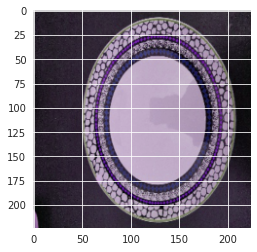

In [235]:
X_batch, y_batch = next(iter(train_dataloader))
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
plt.imshow(X_batch[0].permute(1, 2, 0).numpy()*std+mean)

In [236]:
def show_image_classification(dataloader, title=''):
    
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    try:
        X_batch, y_batch = next(iter(dataloader))
    except:
        X_batch, y_batch, paths = next(iter(test_dataloader))
    
    fig, ax = plt.subplots(2, 3, figsize=(12, 9))

    for x_item, y_item, i, j in zip(X_batch, y_batch, [0, 0, 0, 1, 1, 1], [0, 1, 2, 0, 1, 2]):
    
        image = x_item.permute(1, 2, 0).numpy()
        image = std * image + mean
        
        title = class_names[y_item]
        
        ax[i, j].imshow(image.clip(0, 1))
        ax[i, j].set_title(title)

        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])

    fig.tight_layout()
    plt.show()

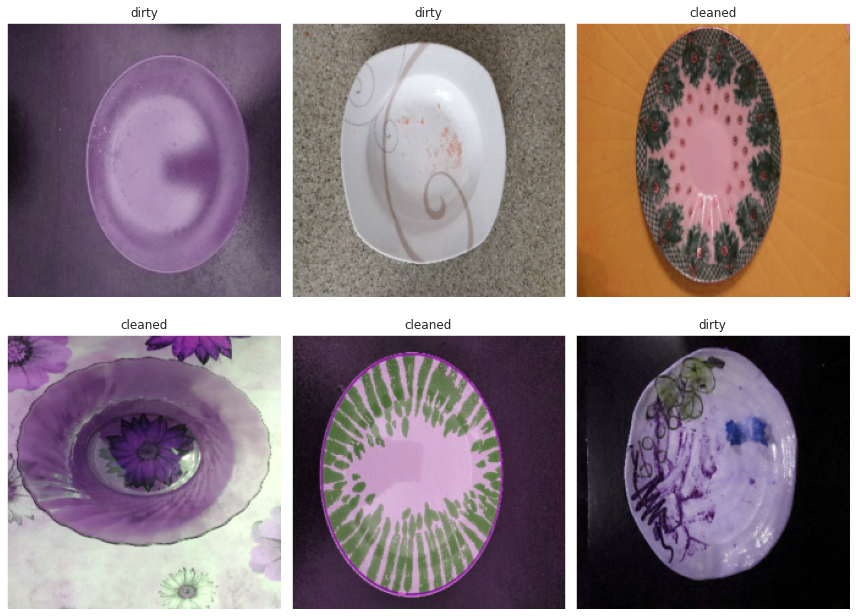

In [237]:
show_image_classification(train_dataloader)

In [238]:
def train_model(model, loss, optimizer, scheduler, num_epochs):
    loss_history = []
    acc_history = []
    n_step = 0
    for epoch in range(num_epochs):
        print('Epoch {}/{}:'.format(epoch, num_epochs - 1), flush=True)
        
        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                dataloader = train_dataloader
                scheduler.step()
                model.train()  # Set model to training mode
            else:
                dataloader = val_dataloader
                model.eval()   # Set model to evaluate mode

            running_loss = 0.
            running_acc = 0.

            # Iterate over data.
            for inputs, labels in tqdm(dataloader):
                n_step +=1
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                # forward and backward
                with torch.set_grad_enabled(phase == 'train'):
                    preds = model(inputs)
                    loss_value = loss(preds, labels)
                    preds_class = preds.argmax(dim=1)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss_value.backward()
                        optimizer.step()

                # statistics
                running_loss += loss_value.data.cpu()
                running_acc += (preds_class == labels.data).float().mean().data.cpu()

#             epoch_loss = running_loss / len(dataloader)
#             epoch_acc = running_acc / len(dataloader)
            
                loss_history.append(running_loss)
                acc_history.append(running_acc)
                
                if (n_step + 1)%10==0:
                #рисуем график
                    clear_output(True)
                    #plt.plot(loss_history, label='loss')
                    plt.plot(acc_history, label='acc')
                    plt.title('Locc&Accuracy')
                    plt.xlabel('batch')
                    plt.ylabel('value')
                    plt.legend(loc='upper left')
                    plt.show()
    
        epoch_loss = running_loss / len(dataloader)
        epoch_acc = running_loss / len(dataloader)

        print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc), flush=True)

    return model

In [239]:
model = models.resnet152(pretrained=True)
#model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet18', pretrained=True)

# Disable grad for all conv layers
for param in model.parameters():
    param.requires_grad = False

model.fc = torch.nn.Linear(model.fc.in_features, 2)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

loss = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

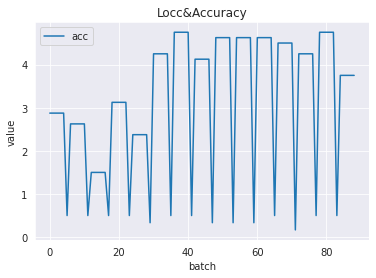

100%|██████████| 1/1 [00:00<00:00,  4.39it/s]

val Loss: 1.6756 Acc: 1.6756


In [240]:
train_model(model, loss, optimizer, scheduler, num_epochs=15);

In [243]:
test_dir = 'test'
shutil.copytree(os.path.join(data_root, 'test'), os.path.join(test_dir, 'unknown'))

'test/unknown'

In [244]:
class ImageFolderWithPaths(torchvision.datasets.ImageFolder):
    def __getitem__(self, index):
        original_tuple = super(ImageFolderWithPaths, self).__getitem__(index)
        path = self.imgs[index][0]
        tuple_with_path = (original_tuple + (path,))
        return tuple_with_path
    
test_dataset = ImageFolderWithPaths('/content/drive/MyDrive/computer vision/plates/plates/test', val_transforms)

test_dataloader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

In [245]:
model.eval()

test_predictions = []
test_img_paths = []
for inputs, labels, paths in tqdm(test_dataloader):
    inputs = transforms.functional.center_crop(inputs, [224, 224])
    inputs = inputs.to(device)
    labels = labels.to(device)
    with torch.set_grad_enabled(False):
        preds = model(inputs)
    test_predictions.append(
        torch.nn.functional.softmax(preds, dim=1)[:,1].data.cpu().numpy())
    test_img_paths.extend(paths)
    
test_predictions = np.concatenate(test_predictions)

100%|██████████| 93/93 [00:09<00:00,  9.42it/s]


In [246]:
submission_df = pd.DataFrame.from_dict({'id': test_img_paths, 'label': test_predictions})

In [247]:
submission_df['label'] = submission_df['label'].map(lambda pred: 'dirty' if pred > 0.5 else 'cleaned')
submission_df['id'] = submission_df['id'].str.replace('/content/drive/MyDrive/computer vision/plates/plates/test', '')
submission_df['id'] = submission_df['id'].str.replace('/unknown/', '')
submission_df['id'] = submission_df['id'].str.replace('.jpg', '')
submission_df.set_index('id', inplace=True)
submission_df.head(n=6)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:4: FutureWarning: The default value of regex will change from True to False in a future version.
  after removing the cwd from sys.path.


,label
id,
0000,dirty
0001,dirty
0002,cleaned
0003,dirty
0004,dirty
0005,dirty


In [248]:
submission_df.to_csv('submission.csv')

In [249]:
from google.colab import files
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [250]:

!rm -rf train val test